# Keyword analysis

In [27]:
import sys

if ".." not in sys.path:
    sys.path.append("..")

import polars as pl
import polars_corpus as plc
import polars.selectors as cs
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import seaborn as sns
import matplotlib.pyplot as plt
from adjustText import adjust_text

In [2]:
bnc = pl.read_parquet("bnc.parquet")
speakers = pl.read_parquet("bnc-speakers.parquet")

In [3]:
speakers = speakers.filter(pl.col("sex").is_in(["m", "f"]))
speakers.group_by("sex").len()

sex,len
str,u32
"""f""",1368
"""m""",2453


In [4]:
bnc = (
    bnc.filter(pl.col("text_type") == "CONVRSN")
    .join(speakers, on="speaker_id", how="inner")
    .with_columns(pl.col("token").str.to_lowercase().alias("norm"))
)

In [6]:
table = (
    bnc.group_by((pl.col("norm") == "fox").alias("is_fuck"), "sex")
    .agg(pl.col("norm").len().alias("count"))
    .with_columns(rel_freq=pl.col("count") / pl.col("count").sum().over("sex"))
    .sort(by=["sex", "is_fuck"])
)
table

is_fuck,sex,count,rel_freq
bool,str,u32,f64
false,"""f""",2745436,0.999961
true,"""f""",106,0.000039
false,"""m""",1784392,0.999815
true,"""m""",331,0.000185


In [7]:
table = np.array(table["count"]).reshape(2, 2)
table

array([[2745436,     106],
       [1784392,     331]], dtype=uint32)

In [8]:
fisher_exact(table)

SignificanceResult(statistic=np.float64(4.804444547551401), pvalue=np.float64(1.3158159886363852e-53))

In [9]:
chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(240.32440578285684), pvalue=np.float64(3.341725556589296e-54), dof=1, expected_freq=array([[2.74527716e+06, 2.64841428e+02],
       [1.78455084e+06, 1.72158572e+02]]))

In [10]:
np.sqrt(chi2_contingency(table).statistic / table.sum())

np.float64(0.007283449863830257)

In [11]:
plc.compute_loglik(plc.crosstab(bnc, pl.col("norm").str.to_lowercase(), "sex")).filter(
    pl.col("sex") == "m", pl.col("f12") > pl.col("f1") * (pl.col("f2") / pl.col("n"))
).sort(by="LL", descending=True)

norm,sex,f12,f1,f2,n,LL
str,str,u32,u32,u32,u32,f64
"""fucking""","""m""",1383,1709,1784723,4530265,1237.920581
"""er""","""m""",9415,18752,1784723,4530265,900.794048
"""the""","""m""",43385,100752,1784723,4530265,574.376875
""",""","""m""",84406,203556,1784723,4530265,380.46747
"""yeah""","""m""",21888,50681,1784723,4530265,305.64689
…,…,…,…,…,…,…
"""pe""","""m""",15,38,1784723,4530265,0.000097
"""charges""","""m""",15,38,1784723,4530265,0.000097
"""twenties""","""m""",15,38,1784723,4530265,0.000097


In [14]:
plc.compute_loglik(plc.crosstab(bnc, pl.col("norm").str.to_lowercase(), "sex")).filter(
    pl.col("sex") == "f", pl.col("f12") > pl.col("f1") * (pl.col("f2") / pl.col("n"))
).sort(by="LL", descending=True)

norm,sex,f12,f1,f2,n,LL
str,str,u32,u32,u32,u32,f64
"""she""","""f""",22807,29844,2745542,4530265,3373.99179
"""her""","""f""",7306,9619,2745542,4530265,1017.03576
"""said""","""f""",12375,17286,2745542,4530265,915.450508
"""n't""","""f""",44380,68601,2745542,4530265,494.184219
"""i""","""f""",93330,148155,2745542,4530265,369.237042
…,…,…,…,…,…,…
"""saving""","""f""",40,66,2745542,4530265,7.1989e-8
"""adult""","""f""",20,33,2745542,4530265,3.5384e-8
"""fox""","""f""",20,33,2745542,4530265,3.5384e-8


In [38]:
keywords = plc.compute_loglik(plc.crosstab(bnc, pl.col("norm").str.to_lowercase(), "sex")).filter(
   pl.col("f12") > pl.col("f1") * (pl.col("f2") / pl.col("n"))
).sort(by="LL", descending=True).head(20)

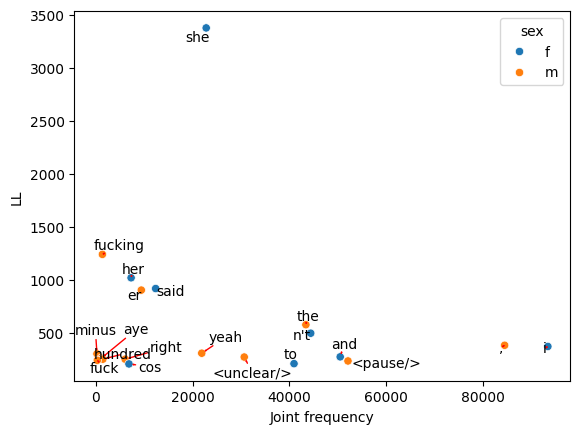

In [40]:
ax = sns.scatterplot(keywords, x='f12', y='LL', hue='sex')

labels = [ ]
for word, f12, ll in keywords.select('norm', 'f12', 'LL').iter_rows():
    labels.append(ax.text(f12, ll, word, ha='center', va='center'))
adjust_text(labels,arrowprops=dict(arrowstyle='->', color='red') )

#plt.loglog()
plt.xlabel('Joint frequency')
plt.show()

<Axes: xlabel='Joint frequency', ylabel='LL'>